In [16]:
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, InputLayer
import keras
import imageio
from PIL import Image 


In [8]:
train = pd.read_csv('agedetectiontrain/train.csv')
test = pd.read_csv('agedetectiontest/test.csv')


Age Group: YOUNG


C:\Users\vigne\AppData\Local\Temp\ipykernel_3372\3589276631.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join('agedetectiontrain/Train', img_name))


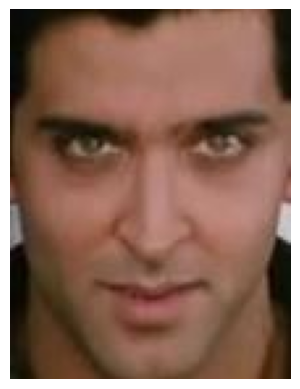

In [11]:
np.random.seed(9)
idx = np.random.choice(train.index)
img_name = train.ID[idx]
img = imageio.v2.imread(os.path.join('agedetectiontrain/Train', img_name))

print('Age Group:', train.Class[idx])
plt.imshow(img)
plt.axis('off')
plt.show()

In [12]:
temp = []
for img_name in train.ID:
    img_path = os.path.join('agedetectiontrain/Train', img_name)
    img = imageio.v2.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32, 32))).astype('float32')    
    temp.append(img)
train_x = np.stack(temp)


C:\Users\vigne\AppData\Local\Temp\ipykernel_3372\4160517167.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


In [13]:
temp = []
for img_name in test.ID:
    img_path = os.path.join('agedetectiontest/Test', img_name)
    img = imageio.v2.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32, 32))).astype('float32')    
    temp.append(img)
test_x = np.stack(temp)


C:\Users\vigne\AppData\Local\Temp\ipykernel_3372\736826803.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


In [14]:
# Normalizing the images
train_x = train_x / 255.
test_x = test_x / 255.


In [17]:
# Encoding the categorical variable to numeric
lb = LabelEncoder()
train_y = lb.fit_transform(train.Class)
train_y = utils.to_categorical(train_y)


Building the ANN

In [18]:
# Specifying all the parameters we will be using in our network
input_num_units = (32, 32, 3)
hidden_num_units = 500
output_num_units = 3
epochs = 5
batch_size = 128


In [19]:
model = Sequential([
  InputLayer(input_shape=input_num_units),
  Flatten(),
  Dense(units=hidden_num_units, activation='relu'),
  Dense(units=output_num_units, activation='softmax'),
])


c:\Users\vigne\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │     1,536,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,538,003 (5.87 MB)

 Trainable params: 1,538,003 (5.87 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compiling and Training Network
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])


In [22]:
model.fit(train_x, train_y, batch_size=batch_size, epochs=epochs, verbose=1)


Epoch 1/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5779 - loss: 0.8935
Epoch 2/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6073 - loss: 0.8430
Epoch 3/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6123 - loss: 0.8277
Epoch 4/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6203 - loss: 0.8167
Epoch 5/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6267 - loss: 0.8059


In [23]:
# Training model along with validation data
model.fit(train_x, train_y, batch_size=batch_size, epochs=epochs, verbose=1, validation_split=0.2)


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6359 - loss: 0.7969 - val_accuracy: 0.6416 - val_loss: 0.7940
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6377 - loss: 0.7926 - val_accuracy: 0.6100 - val_loss: 0.8216
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6397 - loss: 0.7902 - val_accuracy: 0.6507 - val_loss: 0.7781
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6441 - loss: 0.7847 - val_accuracy: 0.6539 - val_loss: 0.7714
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6458 - loss: 0.7851 - val_accuracy: 0.6449 - val_loss: 0.7841


In [25]:
# Predicting and importing the result in a csv file
pred = np.argmax(model.predict(test_x), axis=-1)
pred = lb.inverse_transform(pred)
test['Class'] = pred
test.to_csv('out.csv', index=False)


208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Original: MIDDLE Predicted: ['YOUNG']


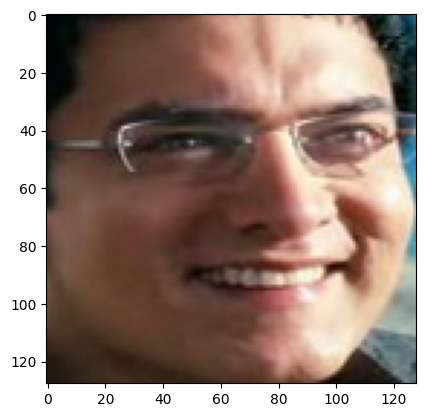

In [29]:
# Visual Inspection of predictions
idx = 2481
img_name = test.ID[idx]
img = imageio.v2.imread(os.path.join('agedetectiontest/Test', img_name)) 
plt.imshow(np.array(Image.fromarray(img).resize((128, 128))))
val_pred = np.argmax(model.predict(test_x), axis=-1) 
print('Original:', train.Class[idx], 'Predicted:', lb.inverse_transform([val_pred[idx]]))
